# 03-05 - What the Camera Wrote Down

A drone photograph is a picture and a record. Beside the pixels, the camera writes into every file when it was taken, where the aircraft was, how high it flew above its take-off point, which way its nose pointed, how long the shutter was open, and which camera took it. That record is what the photogrammetry software reads first, and it is what lets us check a flight against its plan before a single point has been matched.

This notebook reads that record. We open one photograph and take its three metadata tables apart, we recover the camera's pixel size from a number the file states, and we check the camera and the picture mode against what 03-03 planned with. Then we read the whole flight as a table, one row per photograph, and turn positions and time stamps into the step between photographs, the overlap flown, the pattern the aircraft actually traced and how many photographs saw each square metre of the field. We ask which of the three altitudes in the file is which, and we put the sun where it stood during the flight, so that the rule the lecture gave about shadows can be checked rather than assumed.

This notebook was written on the pre-flight of 17 September 2026 and reads the flight named in `data/flight.json`, so the numbers below belong to that flight and the prose tells you where to look rather than what you will see. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json
import math
import re
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio import features
from rasterio.transform import from_origin
from shapely.geometry import Point, box
from shapely.affinity import rotate
from PIL import Image
from PIL.ExifTags import Base, GPS, IFD
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight = json.load(open("data/flight.json"))
reference = json.load(open("data/ground_truth.json"))["p03"]
print(f"this notebook reads the flight {flight['label']} of {flight['date']}: {flight['aircraft']}, {flight['n_photos']} photographs at {flight['altitude_agl_m']} m above the take-off point")

this notebook reads the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3, 85 photographs at 79.3 m above the take-off point


## One photograph, three tables

The kit carries four photographs of the flight, downsized to two thousand pixels wide so that the folder stays small, with their metadata intact except for the camera's serial numbers, which identify an owner and have no place in a public repository. The metadata lives in three places, which the standard calls image file directories, or IFDs, and which are simply named drawers of tags inside the file. The EXIF drawer holds what every digital camera writes, the GPS drawer what a receiver adds, and an XMP packet, which is plain XML text embedded in the file rather than a drawer of tags, holds what the aircraft's maker chose to add. Here are all three for the first photograph:

In [2]:
img = Image.open("data/photo_01.jpg")
exif = img.getexif()
camera = exif.get_ifd(IFD.Exif)                    # the camera's own drawer of tags
gps = exif.get_ifd(IFD.GPSInfo)                    # and the receiver's
print(f"the file is {img.size[0]} by {img.size[1]} pixels; the metadata describes an original of {camera.get(Base.ExifImageWidth)} by {camera.get(Base.ExifImageHeight)}")
print()
print("EXIF, what every camera writes")
print(f"  make and model    {str(exif.get(Base.Make)).strip(chr(0))} {str(exif.get(Base.Model)).strip(chr(0))}")
print(f"  taken             {camera.get(Base.DateTimeOriginal)}  (no time zone is stated)")
print(f"  focal length      {float(camera.get(Base.FocalLength)):.2f} mm, equivalent to {camera.get(Base.FocalLengthIn35mmFilm)} mm on a 35 mm frame")
print(f"  exposure          1/{1 / float(camera.get(Base.ExposureTime)):.0f} s at f/{float(camera.get(Base.FNumber))}, ISO {camera.get(Base.ISOSpeedRatings)}")
print()
print("GPS, what the receiver adds")
lat = tuple(float(v) for v in gps[GPS.GPSLatitude]); lon = tuple(float(v) for v in gps[GPS.GPSLongitude])
altitude_ref = gps[GPS.GPSAltitudeRef]
altitude_ref = int.from_bytes(altitude_ref, "big") if isinstance(altitude_ref, bytes) else int(altitude_ref)   # Pillow hands this one back as a byte
print(f"  latitude          {lat[0]:.0f} deg {lat[1]:.0f} min {lat[2]:.3f} s {gps[GPS.GPSLatitudeRef]}")
print(f"  longitude         {lon[0]:.0f} deg {lon[1]:.0f} min {lon[2]:.3f} s {gps[GPS.GPSLongitudeRef]}")
print(f"  altitude          {float(gps[GPS.GPSAltitude]):.2f} m, reference code {altitude_ref} (0 means above sea level, as the receiver understands it)")
print()
print("XMP, what the aircraft's maker adds")
xmp = img.info.get("xmp", b"")
xmp = xmp.decode("utf-8", "ignore") if isinstance(xmp, bytes) else str(xmp)
for key, value in re.findall(r'drone-dji:(\w+)="([^"]*)"', xmp):    # every DJI field is written drone-dji:Name="value"
    print(f"  {key:22} {value}")

the file is 2000 by 1500 pixels; the metadata describes an original of 4000 by 3000

EXIF, what every camera writes
  make and model    DJI FC3682
  taken             2026:09:23 15:06:53  (no time zone is stated)
  focal length      6.72 mm, equivalent to 24 mm on a 35 mm frame
  exposure          1/500 s at f/1.7, ISO 100

GPS, what the receiver adds
  latitude          40 deg 20 min 38.116 s N
  longitude         74 deg 39 min 15.385 s W
  altitude          17.98 m, reference code 1 (0 means above sea level, as the receiver understands it)

XMP, what the aircraft's maker adds
  AbsoluteAltitude       -17.98
  RelativeAltitude       +76.80
  GimbalRollDegree       +0.00
  GimbalYawDegree        +0.00
  GimbalPitchDegree      +0.00
  FlightRollDegree       +9.50
  FlightYawDegree        -102.30
  FlightPitchDegree      +17.50
  CamReverse             0
  GimbalReverse          0


Read the model line first. The camera calls itself by a code, and DJI's code FC3682 is the Mini 3, which is the aircraft 03-03 plans with; the lecture's first draft assumed a Mini 4 Pro until these files corrected it. A file states a code, not a marketing name, and the code is what settles which camera you have. Then read the pixel count on the line above. 4000 by 3000 is the 4:3 mode, the whole frame the sensor is built for; 4000 by 2250 is the 16:9 mode, which throws a quarter of the rows away before the file is written. Which does yours say, and does it match what 03-03 planned with? Neither fact is visible in the picture, and both change the flight plan, which is why the metadata is read before anything else.

The time has no zone. The camera writes the clock it was set to, and the pipeline that made `photos.csv` assumed the aircraft's clock was on Princeton time, which `flight.json` records. The receiver's altitude comes with a reference code, and we return to what it means below. And the maker's packet carries two altitudes, a relative one above the take-off point and an absolute one, three attitude angles for the aircraft and three for the gimbal. Note the gimbal pitch. It reads zero, which would mean a camera looking at the horizon, and the photograph plainly looks straight down; this aircraft writes zero for a nadir camera, and a metadata field is only as good as the firmware that fills it. Look at the picture before you trust the number:

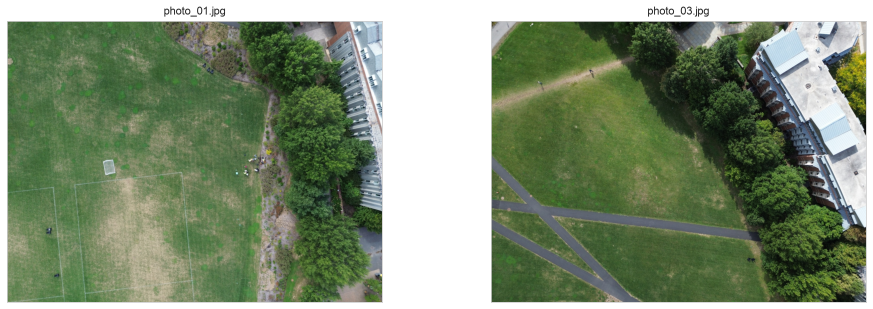

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, name in zip(axes, ("data/photo_01.jpg", "data/photo_03.jpg")):
    ax.imshow(Image.open(name)); ax.set_title(name.split("/")[-1], fontsize=11); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

Two photographs, straight down. A nadir photograph is recognisable without any metadata: the roofs are seen from above rather than from the side, the paths keep their width across the frame, and what lean there is grows outward from the centre, which is the relief displacement of 03-03. A camera at the horizon would have given a skyline. So the gimbal pitch of zero is a lie the firmware tells, and the picture is the evidence against it.

## The pixel pitch from the 35 mm equivalent

The plan's first number, the ground sample distance, needs the size of a pixel on the sensor, and the file does not state it. It states something that implies it: the focal length, and the focal length a 35 mm camera would need for the same field of view. The ratio of the two is the crop factor, the ratio of the 35 mm frame's diagonal of 43.27 mm to this sensor's diagonal. From the diagonal and the frame's proportions comes the sensor's width, and dividing by the pixels across gives the pitch:

In [4]:
focal = float(camera.get(37386)); equivalent = float(camera.get(41989))
diagonal_mm = 43.27 * focal / equivalent
width_px, height_px = camera.get(40962), camera.get(40963)
full_height_px = round(width_px * 3 / 4)                          # the 4:3 frame the sensor is built for
sensor_width_mm = diagonal_mm * width_px / math.hypot(width_px, full_height_px)
pitch_um = sensor_width_mm / width_px * 1000
h = flight["altitude_agl_m"]
gsd_cm = pitch_um * 1e-6 * h / (focal * 1e-3) * 100
print(f"sensor diagonal {diagonal_mm:.2f} mm, width {sensor_width_mm:.2f} mm, pixel pitch {pitch_um:.2f} um   reference {reference['camera']['pixel_um']} um")
print(f"at {h} m the pixel on the ground is {gsd_cm:.2f} cm   reference from the EXIF {reference['flown']['gsd_cm_from_exif']} cm, the plan at 80 m {reference['camera']['gsd_cm']['80']} cm")
print(f"one photograph covers {width_px * gsd_cm / 100:.0f} by {height_px * gsd_cm / 100:.0f} m in the mode flown, against {width_px * gsd_cm / 100:.0f} by {full_height_px * gsd_cm / 100:.0f} m in 4:3")

sensor diagonal 12.12 mm, width 9.69 mm, pixel pitch 2.42 um   reference 2.4 um
at 79.3 m the pixel on the ground is 2.86 cm   reference from the EXIF 2.83 cm, the plan at 80 m 2.86 cm
one photograph covers 114 by 86 m in the mode flown, against 114 by 86 m in 4:3


A pitch of about 2.4 micrometres from the file's own numbers, within a hair of the figure the plan took from the maker's data sheet; the small difference is a 35 mm equivalent rounded to a whole number in the file, and it is why the footprints and counts computed here run a percent from the reference values, which use the maker's 2.4. The ground sample distance follows. Compare the three pixels on the second line, the one this file implies, the one the pipeline read from the whole flight's files, and the plan's at 80 m: a flight higher than planned gives a coarser pixel and a lower one a finer. The last line is the cost of the picture mode. The two footprints are the same across the frame, and along it the 16:9 mode is a quarter shorter than 4:3, which matters because every forward overlap in the plan was a percentage of that along side.

## Where the photographs were taken

Now the whole flight. The pipeline read the same three tables from every photograph into `photos.csv`, one row each, and added the position in the products' coordinate system, EPSG:32618, and the step from the previous photograph in seconds, metres and bearing. Here the camera positions are drawn over the 2022 aerial photograph, coloured from the first exposure to the last:

85 photographs from 2026-09-23 15:06:53 to 2026-09-23 15:21:56 local time, relative altitude 76.8 to 83.8 m   reference 85 photographs, 15.1 min


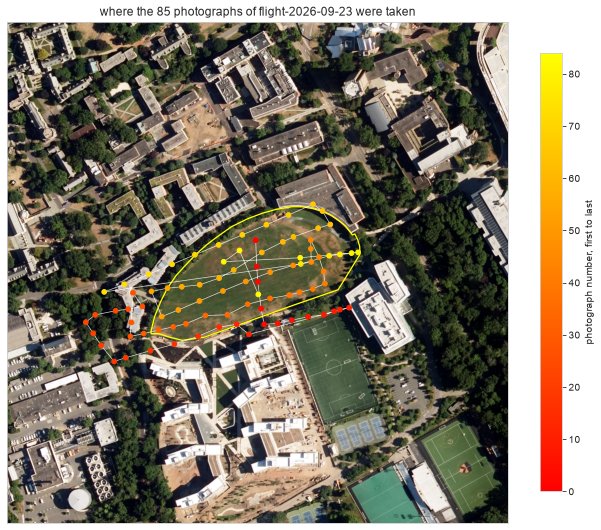

In [5]:
photos = pd.read_csv("data/photos.csv")
site = gpd.read_file("data/site.gpkg", layer="site")
positions = gpd.GeoDataFrame(photos, geometry=gpd.points_from_xy(photos["easting"], photos["northing"]), crs=photos["crs"].iloc[0])
print(f"{len(photos)} photographs from {photos['time_local'].iloc[0]} to {photos['time_local'].iloc[-1]} local time, "
      f"relative altitude {photos['rel_alt_m'].min():.1f} to {photos['rel_alt_m'].max():.1f} m   reference {reference['flown']['n_photos']} photographs, {reference['flown']['duration_min']} min")

with rasterio.open("data/naip_2022_site.tif") as f:
    rgb = f.read([1, 2, 3]).astype("float32")
    lo, hi = np.percentile(rgb, 1, axis=(1, 2)), np.percentile(rgb, 99, axis=(1, 2))
    rgb = np.moveaxis(np.clip((rgb - lo[:, None, None]) / (hi - lo)[:, None, None], 0, 1), 0, -1)
    extent = (f.bounds.left, f.bounds.right, f.bounds.bottom, f.bounds.top)
    naip_crs = f.crs
in_naip = positions.to_crs(naip_crs)

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(rgb, extent=extent)
site.to_crs(naip_crs).boundary.plot(ax=ax, color="yellow", linewidth=1.3)
ax.plot(in_naip.geometry.x, in_naip.geometry.y, color="white", linewidth=0.7, alpha=0.8)
sc = ax.scatter(in_naip.geometry.x, in_naip.geometry.y, c=np.arange(len(in_naip)), cmap="autumn", s=22, zorder=3)
fig.colorbar(sc, ax=ax, shrink=0.7, label="photograph number, first to last")
ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3]); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"where the {len(photos)} photographs of {flight['label']} were taken", fontsize=12)
fig.tight_layout()

Compare the white path with the plan of 03-03. The plan was five parallel strips flown back and forth along the field's long side. On the pre-flight of 17 September the aircraft traced loops around the field instead, from the outside in, because of how the mission was set, and the nose kept one heading for most of the flight while the aircraft moved sideways and backwards along the loops. A flight is what the aircraft did, not what the plan said, and the positions in the files are the record of it. Whether that matters for the model is a question the next two sections answer with numbers.

## The step between photographs

The step from one photograph to the next, in seconds and in metres, is the interval the pilot set and the speed the aircraft held, and the metres along the direction of flight are the base of 03-03. The forward overlap is one minus the base over the frame's along side, which is the side the picture mode above decides:

a photograph every 3.0 s at 4.69 m/s, a base of 19.1 m   reference 3.0 s, 4.69 m/s, 19.1 m
forward overlap in the mode flown 77.7 percent   reference 77.5 percent; the plan wanted 17.14 m and 80 percent
the same base in the 4:3 mode would have given 77.7 percent
for the camera and the height actually flown the plan would have wanted 5 strips of 17, 95 photographs, a photograph every 3.4 s at 5 m/s


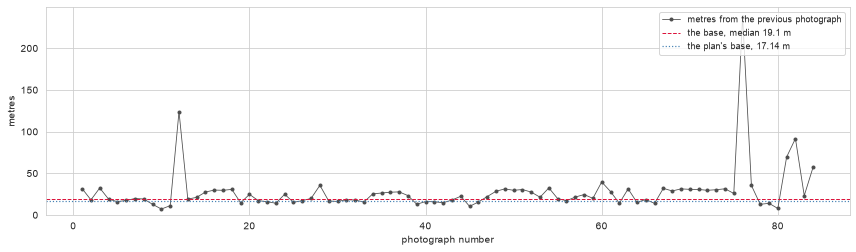

In [6]:
# the turns and transits cover more ground than the interval implies, so they are dropped before the base is taken
between_exposures = photos[photos["seconds_from_previous"] <= photos["seconds_from_previous"].median() * 1.5]
interval = photos["seconds_from_previous"].median()
speed = photos["speed_m_s"].median()
base = between_exposures["metres_from_previous"].median()
along_flown = height_px * gsd_cm / 100
along_4_3 = full_height_px * gsd_cm / 100
print(f"a photograph every {interval:.1f} s at {speed:.2f} m/s, a base of {base:.1f} m   reference {reference['flown']['median_interval_s']} s, {reference['flown']['median_speed_m_s']} m/s, {reference['flown']['median_base_m']} m")
print(f"forward overlap in the mode flown {100 * (1 - base / along_flown):.1f} percent   reference {reference['flown']['forward_overlap_pct']} percent; the plan wanted {reference['plan']['overlap_80_70']['base_m']} m and 80 percent")
print(f"the same base in the 4:3 mode would have given {100 * (1 - base / along_4_3):.1f} percent")
plan_here = reference["flown"]["plan_for_this_camera_and_height"]
print(f"for the camera and the height actually flown the plan would have wanted {plan_here['n_strips']} strips of {plan_here['n_per_strip']}, {plan_here['n_photos']} photographs, a photograph every {plan_here['interval_s']:.1f} s at 5 m/s")

fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(photos.index, photos["metres_from_previous"], marker="o", markersize=3, linewidth=0.8, color="0.3", label="metres from the previous photograph")
ax.axhline(base, color="crimson", linestyle="--", linewidth=1, label=f"the base, median {base:.1f} m")
ax.axhline(reference["plan"]["overlap_80_70"]["base_m"], color="steelblue", linestyle=":", linewidth=1.2, label=f"the plan's base, {reference['plan']['overlap_80_70']['base_m']} m")
ax.set_xlabel("photograph number"); ax.set_ylabel("metres"); ax.legend(loc="upper right", fontsize=9); ax.set_ylim(0, None)
fig.tight_layout()

Read the three numbers on the first line against the plan's on the same line. The interval is what the pilot set, the speed is what the aircraft held, and the base is the product of the two, so a longer base is either a slower shutter or a faster aircraft. The second line turns that base into the overlap actually flown. On the pre-flight of 17 September the interval was five seconds rather than the three the plan chose, and the aircraft flew slower than 5 m/s, which partly compensated; that, and the short 16:9 frame the third line prices, took the forward overlap from the planned eighty percent to about seventy, which is the classical value of Wolf's day and enough for the software to work with, but not what the plan bought. The last line says what the plan would have asked for with the camera and the height actually flown, which is a useful thing to know before you blame a flight for missing a plan it was never given.

The spikes in the plot are the turns and the transits, where the aircraft covered more ground between two exposures than it did along a leg. They are excluded from the median base above, which is what `between_exposures` is for, and they are not lost overlap either, because the footprints of neighbouring legs overlap sideways. The next section counts that.

## How many photographs see each cell

Overlap along the path is one thing; what matters to the model is how many photographs see each piece of ground. We draw every photograph's footprint from its position and its yaw, the long side across the nose direction as 03-03 assumed, rasterise them onto a 2 m grid and count:

inside the field every cell is in 6 to 28 photographs, 17 in the middle   reference 6 to 28, median 17
the plan of 03-03 would have given 10 to 21, median 14


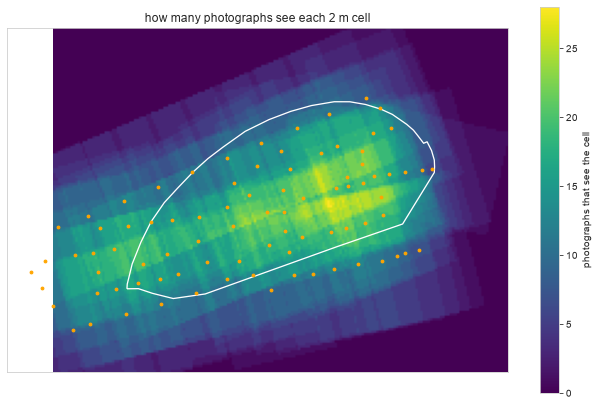

In [7]:
site_utm = site.to_crs(positions.crs).geometry.iloc[0]
across_m = width_px * gsd_cm / 100
footprints = []
for x, y, yaw in zip(photos["easting"], photos["northing"], photos["flight_yaw_deg"].fillna(0)):
    frame = box(x - across_m / 2, y - along_flown / 2, x + across_m / 2, y + along_flown / 2)   # the long side across the nose, as 03-03 assumed
    footprints.append(rotate(frame, -yaw, origin=(x, y)))                                      # yaw runs clockwise from north, rotation anticlockwise
x0, y0, x1, y1 = site_utm.buffer(60).bounds
cell = 2.0
w, h_cells = math.ceil((x1 - x0) / cell), math.ceil((y1 - y0) / cell)
transform = from_origin(x0, y1, cell, cell)
counts = np.zeros((h_cells, w), dtype="int16")
for fp in footprints:
    counts += features.rasterize([(fp, 1)], out_shape=(h_cells, w), transform=transform, fill=0, dtype="int16")
inside = features.rasterize([(site_utm, 1)], out_shape=(h_cells, w), transform=transform, fill=0, dtype="uint8").astype(bool)
cov = reference["flown"]["coverage_inside_site"]
plan_cov = reference["plan"]["overlap_80_70"]["coverage_inside_site"]
print(f"inside the field every cell is in {counts[inside].min()} to {counts[inside].max()} photographs, {np.median(counts[inside]):.0f} in the middle"
      f"   reference {cov['min']} to {cov['max']}, median {cov['median']}")
print(f"the plan of 03-03 would have given {plan_cov['min']} to {plan_cov['max']}, median {plan_cov['median']}")

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(counts, extent=(x0, x1, y0, y1), cmap="viridis", vmin=0, vmax=max(20, int(counts.max())))
gpd.GeoSeries([site_utm], crs=positions.crs).boundary.plot(ax=ax, color="white", linewidth=1.3)
ax.scatter(photos["easting"], photos["northing"], color="orange", s=8, zorder=3)
fig.colorbar(im, ax=ax, shrink=0.8, label="photographs that see the cell")
ax.set_title("how many photographs see each 2 m cell", fontsize=12); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

This is the number that decides whether a flight was good enough, and the minimum is the one to read first. Two photographs are the fewest that give a height at all, under three the software can barely place a cell, and under five it will be noisy there. Then read the map rather than the average. The count is highest where the aircraft passed most often and thins toward the edges of the block, and the software has the most to work with where the count is high. On the pre-flight of 17 September the loops bought the minimum back: the aircraft passed near every part of the field more than once and from different sides, so the sideways overlap made up for the longer base, though a plan of parallel strips would have spread the count more evenly.

## Which altitude

Three altitudes travel in every file, and they do not agree. The maker's relative altitude is height above the take-off point, measured by the barometer. The maker's absolute altitude and the receiver's GPS altitude are the aircraft's estimate of its height above sea level, and the receiver's notion of sea level is the ellipsoid of 03-04, thirty three metres above the NAVD88 zero the 3DEP terrain model uses. Put them side by side with the ground:

In [8]:
ground = reference["terrain"]["site_ground_m"]
n_geoid = reference["terrain"]["geoid18_n_m"]
rel, absolute, gps_alt = photos["rel_alt_m"].median(), photos["abs_alt_m"].median(), photos["gps_alt_m"].median()
print(f"relative altitude, above the take-off point      {rel:6.1f} m")
print(f"absolute altitude, the maker's field             {absolute:6.1f} m")
print(f"GPS altitude, the receiver's field               {gps_alt:6.1f} m")
print(f"the field's ground above NAVD88, from 3DEP      {ground:6.1f} m, so the aircraft was at about {ground + rel:.1f} m above NAVD88")
print(f"the same height above the ellipsoid, with N = {n_geoid} m       {ground + rel + n_geoid:.1f} m")
print(f"the receiver's absolute altitude is {ground + rel + n_geoid - absolute:.1f} m from even that")
print(f"for comparison, 03-07 measures the receiver's height error on the lawn as {reference['heights']['receiver_height_error_m']} m; this line measures it at the aircraft, barometer and all")

relative altitude, above the take-off point        79.3 m
absolute altitude, the maker's field              -15.5 m
GPS altitude, the receiver's field                 15.5 m
the field's ground above NAVD88, from 3DEP        41.9 m, so the aircraft was at about 121.2 m above NAVD88
the same height above the ellipsoid, with N = -33.27 m       87.9 m
the receiver's absolute altitude is 103.4 m from even that
for comparison, 03-07 measures the receiver's height error on the lawn as -95.61 m; this line measures it at the aircraft, barometer and all


The relative altitude is the one to trust for the flight plan, and it is the one to compare with the height 03-03 planned; it is measured from wherever the aircraft took off, so it agrees with the plan only if the take-off point and the field are at the same height. The absolute altitudes are another matter. Even after moving the terrain model's NAVD88 height onto the ellipsoid, the receiver's number differs by metres; look at the sign of the last line as well as its size, since a receiver can be wrong in either direction. It is the quality of a consumer receiver's height, which is the worst of its three coordinates, plus whatever the barometer drifted since take-off. Every point cloud and surface model built from these positions inherits that offset, which is the number 03-07 measures against the 3DEP terrain and states before it removes it.

## The sun during the flight

The lecture's weather rule asked for the sun above thirty degrees, so that shadows stay short and the ground beside every wall and every tree is lit. The time stamps say when the flight happened, and the solar position algorithm of 03-04 says where the sun was. It is copied in below so that this notebook stands on its own; nothing here asks you to read it, only to use it:

In [9]:
def sun_position(when_utc, lat, lon):
    '''Solar elevation and azimuth in degrees, azimuth clockwise from north, the NOAA solar calculator's algorithm; longitude positive east.'''
    jd = when_utc.toordinal() + 1721424.5 + (when_utc.hour + when_utc.minute / 60 + when_utc.second / 3600) / 24
    T = (jd - 2451545.0) / 36525
    L0 = (280.46646 + T * (36000.76983 + 0.0003032 * T)) % 360
    M = math.radians(357.52911 + T * (35999.05029 - 0.0001537 * T))
    C = (1.914602 - T * (0.004817 + 0.000014 * T)) * math.sin(M) + (0.019993 - 0.000101 * T) * math.sin(2 * M) + 0.000289 * math.sin(3 * M)
    omega = math.radians(125.04 - 1934.136 * T)
    app_long = math.radians(L0 + C - 0.00569 - 0.00478 * math.sin(omega))
    eps = math.radians(23.439291 - 0.0130042 * T + 0.00256 * math.cos(omega))
    decl = math.asin(math.sin(eps) * math.sin(app_long))
    y = math.tan(eps / 2) ** 2
    L0r = math.radians(L0)
    e = 0.016708634 - T * (0.000042037 + 0.0000001267 * T)
    eot = 4 * math.degrees(y * math.sin(2 * L0r) - 2 * e * math.sin(M) + 4 * e * y * math.sin(M) * math.cos(2 * L0r)
                           - 0.5 * y * y * math.sin(4 * L0r) - 1.25 * e * e * math.sin(2 * M))
    minutes = when_utc.hour * 60 + when_utc.minute + when_utc.second / 60
    tst = (minutes + eot + 4 * lon) % 1440
    ha_deg = tst / 4 - 180 if tst / 4 >= 0 else tst / 4 + 180
    ha, latr = math.radians(ha_deg), math.radians(lat)
    zen = math.acos(math.sin(latr) * math.sin(decl) + math.cos(latr) * math.cos(decl) * math.cos(ha))
    a = math.degrees(math.acos(((math.sin(latr) * math.cos(zen)) - math.sin(decl)) / (math.cos(latr) * math.sin(zen))))
    return 90 - math.degrees(zen), (a + 180) % 360 if ha_deg > 0 else (540 - a) % 360

lon_c, lat_c = reference["site"]["centre_lonlat"]
guyot_m = reference["shadows"]["buildings"][0]["height_m"]         # the building 03-04 measured from its shadow
for label, row in (("first photograph", photos.iloc[0]), ("last photograph", photos.iloc[-1])):
    when = dt.datetime.strptime(row["time_utc"], "%Y-%m-%d %H:%M:%S")
    elev, az = sun_position(when, lat_c, lon_c)
    shadow_m = guyot_m / math.tan(math.radians(elev))
    print(f"{label:17} {row['time_local']} local, sun {elev:.1f} degrees high at azimuth {az:.0f}; a {guyot_m:.0f} m building casts a {shadow_m:.0f} m shadow")
print(f"reference {reference['flown']['sun_elevation_deg_start']} to {reference['flown']['sun_elevation_deg_end']} degrees; the lecture's rule wanted more than 30")

READOUT_MS = 30                                                   # an assumption: DJI does not publish this sensor's readout time
exposure = photos["exposure_s"].median()
blur_m = speed * exposure                                         # how far the aircraft moves while the shutter is open
skew_m = speed * READOUT_MS / 1000                                # and while the sensor is read out, line by line
print(f"motion blur at {speed:.2f} m/s and 1/{1 / exposure:.0f} s: {blur_m * 100:.1f} cm, {blur_m / (gsd_cm / 100):.2f} pixels")
print(f"rolling shutter skew over an assumed {READOUT_MS} ms readout: {skew_m * 100:.0f} cm, {skew_m / (gsd_cm / 100):.1f} pixels")

first photograph  2026-09-23 15:06:53 local, sun 38.9 degrees high at azimuth 226; a 14 m building casts a 18 m shadow
last photograph   2026-09-23 15:21:56 local, sun 36.8 degrees high at azimuth 230; a 14 m building casts a 19 m shadow
reference 38.9 to 36.8 degrees; the lecture's rule wanted more than 30
motion blur at 4.69 m/s and 1/1000 s: 0.5 cm, 0.16 pixels
rolling shutter skew over an assumed 30 ms readout: 14 cm, 4.9 pixels


Read the two elevations against the rule. On the pre-flight of 17 September the sun stood about twenty degrees high, late in the afternoon, and Guyot Hall's shadow came out more than twice its own height; the rule was broken because the flight was fitted around a day, which is how most flights happen. The price is paid in the orthomosaic, where the ground on the shaded side of every tree and wall is dark and the software has less to match there. The class flight is in the early afternoon with the sun far higher, and 03-06 lets you compare the two.

The last two lines are the blurs the lecture named. At a short exposure the aircraft's motion smears the picture by a fraction of a pixel, which is nothing. The rolling shutter reads the sensor line by line over tens of milliseconds, and in that time the aircraft moves several pixels, which is why the processing was told to correct for it. Note that the readout time is an assumption and not a measurement; the maker does not publish it, so that line is an order of magnitude rather than a number.

## The second flight

A flight of the same field at another height is worth having, and the pre-flight of 17 September was flown twice for that reason, the second time at about 120 m. Where the flight record lists such a flight and the kit carries its table, the cell below reads it with the same arithmetic. Same camera, same interval, a coarser pixel and a larger footprint:

In [10]:
others = flight.get("other_flights", {})
if not others:
    print("this flight was flown once; there is no second flight to compare with")
for name in others:
    table = f"data/photos_{name}.csv"                       # the file's name follows the label in flight.json
    if not Path(table).exists():
        print(f"the {name} flight has no table in the kit")
        continue
    second = pd.read_csv(table)
    h2 = second["rel_alt_m"].median()
    gsd2 = pitch_um * 1e-6 * h2 / (focal * 1e-3) * 100
    steady2 = second[second["seconds_from_previous"] <= second["seconds_from_previous"].median() * 1.5]
    base2 = steady2["metres_from_previous"].median()
    along2 = height_px * gsd2 / 100
    other = reference["other_flights"][name]
    print(f"the {name} flight: {len(second)} photographs at {h2:.0f} m, pixel {gsd2:.2f} cm, footprint {width_px * gsd2 / 100:.0f} by {along2:.0f} m, "
          f"base {base2:.1f} m, forward overlap {100 * (1 - base2 / along2):.1f} percent")
    print(f"reference {other['n_photos']} photographs, {other['gsd_cm_from_exif']} cm, {other['forward_overlap_pct']} percent, "
          f"every cell of the field in {other['coverage_inside_site']['min']} to {other['coverage_inside_site']['max']} photographs")

this flight was flown once; there is no second flight to compare with


Compare the two rows rather than remember them. Flying higher enlarges the footprint in both directions, so the same interval gives a longer along side to divide the base into and therefore more overlap from fewer photographs, at the price of a coarser pixel. Two flights of one field on one afternoon are a controlled experiment in the trade 03-03 described, and 03-06 puts their orthomosaics side by side.

## Your turn

The flight pattern is in the bearings. Where the bearing from one photograph to the next turns by more than sixty degrees, the aircraft turned a corner. Count the corners, split the flight into legs at them, and report how many photographs each leg holds. Then say in a sentence what shape the legs describe, and whether the software will care.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [11]:
# Your attempt. photos["bearing_from_previous_deg"] is the direction of travel into each photograph, clockwise from north.
#
# turn = photos["bearing_from_previous_deg"].diff().abs()
# turn = np.minimum(turn, 360 - turn)                   # a turn is never more than 180 degrees
# corner = turn > ___
# leg = corner.cumsum()
# print(f"{int(corner.sum())} corners, {leg.nunique()} legs, photographs per leg:", leg.value_counts().sort_index().tolist())

## Check your understanding

1. Your files state a pixel count. Say which of the plan's numbers change if the camera was set to 16:9 rather than 4:3, which do not, and in which direction the forward overlap moves.
2. Three altitudes appear in the metadata. Which one would you use to check the flying height, which to place the model on the Earth, and what does each still need before it can be compared with the 3DEP terrain model?
3. The gimbal pitch read zero for a camera pointing straight down. Give one way to check a metadata field against the picture it describes, for pitch, for time and for position.
4. Read the sun's elevation this notebook printed for your flight. Name two things in the orthomosaic that will show it, and say why the lecture's rule asked for more than thirty degrees.

## Where we are

You can open a photograph and read its three metadata tables, and you know which of them every camera writes, which the receiver adds and which the maker chose to add. You have recovered the pixel pitch from the 35 mm equivalent, found that the camera and the picture mode were not the plan's, and computed what that did to the footprint and the overlap. You have turned time stamps and positions into an interval, a speed, a base and a coverage count, and you can say whether a flight was good enough from its metadata alone. And you know that a file carries three altitudes with three meanings and a gimbal angle that lies.

The habit worth keeping: before you process a flight, tabulate its metadata and check the camera, the mode, the interval, the altitude and the sun against the plan; a bad flight is cheaper to find in a table than in a point cloud.

In 03-06 we open the orthomosaic the software built from these photographs, read its tiles, its overviews and its edges, and set the drone's resolution beside the State's and the federal flights on one grid.

## Further resources

Nothing in this course requires anything below.

The EXIF standard is CIPA DC-008, published by the Camera and Imaging Products Association: https://www.cipa.jp/e/std/std-sec.html. Pillow's documentation covers `getexif`, the IFDs and the XMP packet: https://pillow.readthedocs.io/en/stable/reference/Image.html

OpenDroneMap's documentation explains how the software uses the positions in the files and what accuracy it assumes for them: https://docs.opendronemap.org/arguments/gps-accuracy/. The maker's XMP fields are documented by the community rather than by DJI; the exiftool tag tables list them: https://exiftool.org/TagNames/DJI.html

The solar position algorithm is the one behind NOAA's solar calculator: https://gml.noaa.gov/grad/solcalc/

The photographs and their tables are the course's own flight, published under CC BY 4.0 and checked to show no recognisable person. The 2022 aerial photograph is USDA NAIP, public domain. The outline of Poe Field is an OpenStreetMap extract, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The corners and the legs, read from the table itself so that the cell stands on its own:

```python
import numpy as np
import pandas as pd

photos = pd.read_csv("data/photos.csv")
turn = photos["bearing_from_previous_deg"].diff().abs()
turn = np.minimum(turn, 360 - turn)
corner = turn > 60
leg = corner.cumsum()
print(f"{int(corner.sum())} corners, {leg.nunique()} legs, photographs per leg:", leg.value_counts().sort_index().tolist())
```

On the pre-flight the legs are the sides of loops rather than parallel strips, and their lengths shrink from the outer loop to the inner ones. The software does not care about the pattern as long as every point of the ground appears in enough photographs from enough directions, which the coverage count above confirmed; what it does care about is that the photographs overlap in sequence and sideways, and loops give both. What a pilot cares about is that a plan can be repeated. Strips can; loops drawn by hand cannot, which is why the class flight flies the plan of 03-03.